<a href="https://colab.research.google.com/github/bingxiaochen/ST554/blob/main/ST_554_HW6_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bing Chen

ST 554 HW6

3/8/2026

# Part 1.

1.

First read in the `sqlite3` and `pandas` module and make connection to the database.



In [22]:
#bring in the module
import sqlite3
import pandas as pd

#make the connection to the .db file. My file is in the main folder on the left
con = sqlite3.connect("lahman_1871-2022.sqlite")


get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''



Then get the tables.

In [23]:
schema_df2 = pd.read_sql(get_schema, con)
schema_df2

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


2. Return a table of hall of fame pitchers and their statistics

In [24]:
tab = pd.read_sql("""
SELECT DISTINCT m.playerID,
    SUM(m.W) AS Total_Win,
    SUM(m.L) AS Total_Loss,
    SUM(m.GS) AS Total_GS,
    SUM(m.G) AS Total_G,
    SUM(m.IPOuts) AS Total_IPOuts,
    SUM(m.CG) AS Total_CG,
    SUM(m.SHO) AS Total_SHO,
    SUM(m.SV) AS Total_SV
FROM pitching m
INNER JOIN HallOfFame h
ON m.playerID = h.playerID
WHERE h.inducted = 'Y'
GROUP BY m.playerID;

""", con)

tab


,playerID,Total_Win,Total_Loss,Total_GS,Total_G,Total_IPOuts,Total_CG,Total_SHO,Total_SV
0,alexape01,373,208,599,696,15570,437,90,32
1,ansonca01,0,1,0,3,12,0,0,1
2,becklja01,0,1,1,1,12,0,0,0
3,bendech01,212,127,334,459,9051,255,40,34
4,blylebe01,287,250,685,692,14910,242,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,249,205,471,513,11988,388,50,11
104,wrighge01,0,1,0,3,15,0,0,0
105,wrighha01,4,4,8,36,301,0,0,14
106,wynnea01,300,244,612,691,13692,290,49,15


3. For all of the hall of fame pitchers, create a table of their batting statistics.

In [25]:
stat = pd.read_sql("""
SELECT DISTINCT m.playerID,
    SUM(m.AB) AS Total_AB,
    SUM(m.R) AS Total_R,
    SUM(m.H) AS Total_H,
    SUM(m.HR) AS Total_HR,
    SUM(m.RBI) AS Total_RBI,
    SUM(m.BB) AS Total_BB,
    SUM(m.SO) AS Total_SO
FROM batting as m
INNER JOIN HallOfFame h
ON m.playerID = h.playerID
WHERE h.inducted = 'Y'
GROUP BY m.playerID;

""", con)

stat


,playerID,Total_AB,Total_R,Total_H,Total_HR,Total_RBI,Total_BB,Total_SO
0,aaronha01,12364,2174,3771,755,2297,1402,1383
1,alexape01,1810,154,378,11,163,77,276
2,alomaro01,9073,1508,2724,210,1134,1032,1140
3,alstowa01,1,0,0,0,0,0,1
4,andersp01,477,42,104,0,34,42,53
...,...,...,...,...,...,...,...,...
266,wynnea01,1704,136,365,17,173,141,330
267,yastrca01,11988,1816,3419,452,1844,1845,1393
268,youngcy01,2960,325,623,18,290,81,381
269,youngro01,4627,812,1491,42,592,550,390


4. Merge the tables together


In [26]:
player_stats = pd.merge(
 left = tab,
 right = stat,
 how = "inner",
 on = "playerID")

player_stats

,playerID,Total_Win,Total_Loss,Total_GS,Total_G,Total_IPOuts,Total_CG,Total_SHO,Total_SV,Total_AB,Total_R,Total_H,Total_HR,Total_RBI,Total_BB,Total_SO
0,alexape01,373,208,599,696,15570,437,90,32,1810,154,378,11,163,77,276
1,ansonca01,0,1,0,3,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,0,1,1,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,212,127,334,459,9051,255,40,34,1147,102,243,6,116,75,143
4,blylebe01,287,250,685,692,14910,242,60,0,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,249,205,471,513,11988,388,50,11,1493,107,248,1,84,81,199
104,wrighge01,0,1,0,3,15,0,0,0,2873,665,866,11,326,68,119
105,wrighha01,4,4,8,36,301,0,0,14,813,183,224,4,113,37,14
106,wynnea01,300,244,612,691,13692,290,49,15,1704,136,365,17,173,141,330


# Part 2

Example code:

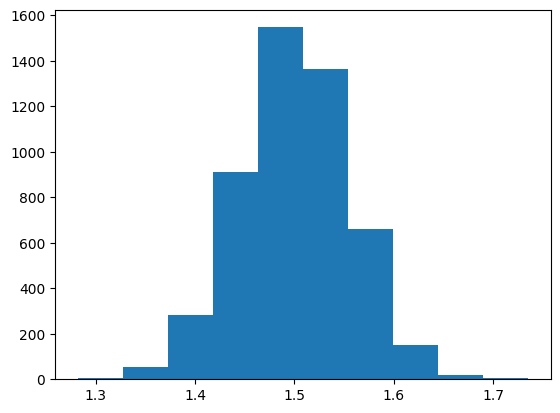

In [27]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()

#Create a reg object
#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))

for i in range(5000):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    #find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

In [28]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)